<a href="https://colab.research.google.com/github/juanepstein99/DI_Bootcamp/blob/main/Week10/Day6/DailyChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Daily Challenge: Analysis of Airplane Crashes and Fatalities**

**Tasks:**

**1. Data Import and Cleaning:**
* Import the dataset using Pandas.
* Clean and preprocess the data, addressing missing values and categorizing data as needed.
* Convert dates and other relevant fields to appropriate formats.

**2. Exploratory Data Analysis:**
* Use Pandas to explore basic statistics such as the number of crashes, fatalities, and survival rates.
* Analyze the frequency of crashes over time to identify any trends.

**3. Statistical Analysis:**
* Apply SciPy to analyze the distribution of fatalities and survival rates. Calculate key statistics like mean, median, and standard deviation.
* Conduct a hypothesis test (e.g., comparing the average number of fatalities in different decades or regions).

**4. Visualization:**
* Create charts and graphs using Matplotlib and Seaborn to visualize the findings from your exploratory data analysis and statistical tests.
* Examples might include time series plots of crashes over years, bar charts of crashes by region, and histograms of fatalities.

**5. Insight and Report:**
* Summarize your findings and provide insights into the patterns or anomalies discovered in the data.
* Prepare a well-structured report including all code, visualizations, and interpretations.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set()

In [6]:
# 1. Data Import and Cleaning:

df = pd.read_csv("Airplane_Crashes_Fatalities.csv", encoding="latin1")

print(df.head())

# convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# create Year column
df["Year"] = df["Date"].dt.year

# drop rows without Year
df = df.dropna(subset=["Year"])

# fill missing values
df["Fatalities"] = df["Fatalities"].fillna(0)
df["Aboard"] = df["Aboard"].fillna(0)

# create survival rate
df["Survival_Rate"] = np.where(
    df["Aboard"] > 0,
    (df["Aboard"] - df["Fatalities"]) / df["Aboard"],
    0
)

        Date   Time                            Location  \
0  9/17/1908  17:18                 Fort Myer, Virginia   
1   9/7/1909    NaN             Juvisy-sur-Orge, France   
2  7/12/1912   6:30           Atlantic City, New Jersey   
3   8/6/1913    NaN  Victoria, British Columbia, Canada   
4   9/9/1913  18:30                  Over the North Sea   

                 Operator Flight #          Route                 AC Type  \
0    Military - U.S. Army      NaN  Demonstration        Wright Flyer III   
1                     NaN      NaN       Air show          Wright Byplane   
2    Military - U.S. Navy      NaN    Test flight               Dirigible   
3                 Private      NaN            NaN        Curtiss seaplane   
4  Military - German Navy      NaN            NaN  Zeppelin L-1 (airship)   

  Registration cn/ln  Aboard  Aboard Passangers  Aboard Crew  Fatalities  \
0          NaN     1     2.0                1.0          1.0         1.0   
1          SC1   NaN     1.0  

Total crashes: 4998
Total fatalities: 111644.0
Average survival rate: 0.18065383586849784


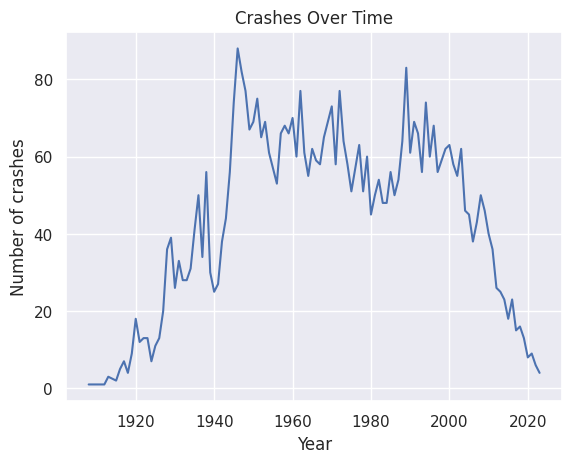

In [7]:
# 2. Exploratory Data Analysis:

# total crashes
print("Total crashes:", len(df))

# total fatalities
print("Total fatalities:", df["Fatalities"].sum())

# average survival rate
print("Average survival rate:", df["Survival_Rate"].mean())

# crashes per year
crashes_per_year = df.groupby("Year").size()

# plot crashes over time
plt.figure()
plt.plot(crashes_per_year.index, crashes_per_year.values)
plt.title("Crashes Over Time")
plt.xlabel("Year")
plt.ylabel("Number of crashes")
plt.grid(True)
plt.show()

Mean fatalities: 22.337735094037615
Median fatalities: 11.0
Std fatalities: 35.04508061393761


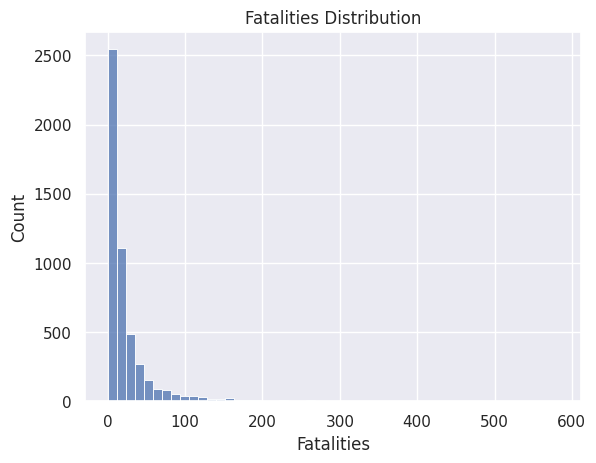

T-stat: 3.0635157641167265
P-value: 0.002242973423060483


In [9]:
# 3. Statistical Analysis:

# mean, median, std
print("Mean fatalities:", df["Fatalities"].mean())
print("Median fatalities:", df["Fatalities"].median())
print("Std fatalities:", df["Fatalities"].std())

# fatalities distribution
plt.figure()
sns.histplot(df["Fatalities"], bins=50)
plt.title("Fatalities Distribution")
plt.xlabel("Fatalities")
plt.ylabel("Count")
plt.show()

# HYPOTHESIS TEST

# create decade column
df["Decade"] = (df["Year"] // 10) * 10

# compare two decades (example)
decade_80 = df[df["Decade"] == 1980]["Fatalities"]
decade_2000 = df[df["Decade"] == 2000]["Fatalities"]

# t-test
t_stat, p_value = stats.ttest_ind(decade_80, decade_2000, nan_policy='omit')

print("T-stat:", t_stat)
print("P-value:", p_value)

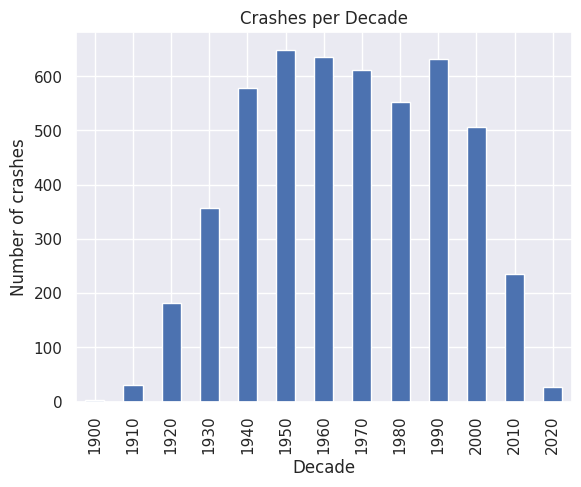

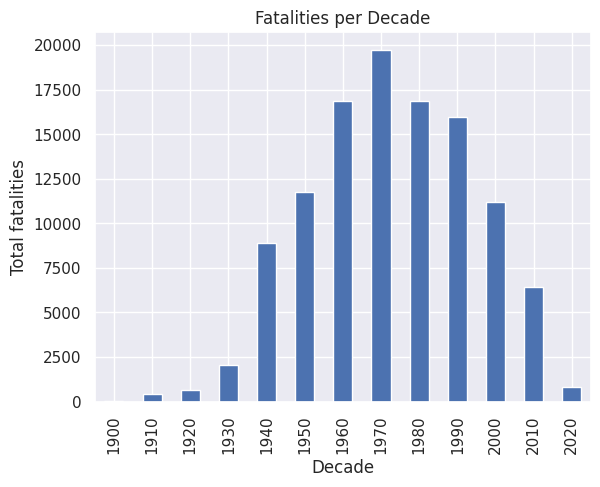

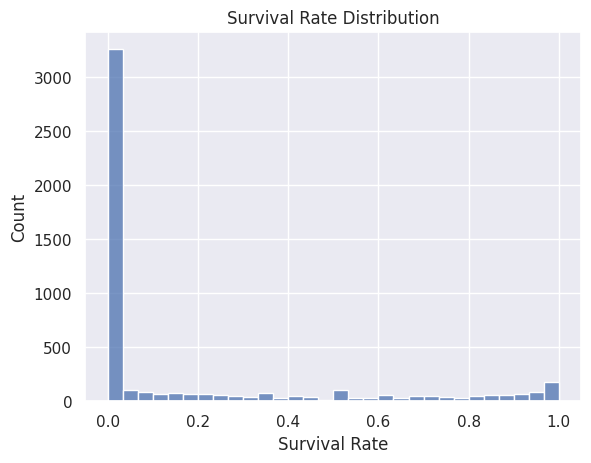

In [10]:
# 4. Visualization:

# crashes per decade
crashes_per_decade = df.groupby("Decade").size()

plt.figure()
crashes_per_decade.plot(kind="bar")
plt.title("Crashes per Decade")
plt.xlabel("Decade")
plt.ylabel("Number of crashes")
plt.show()

# fatalities per decade
fatalities_per_decade = df.groupby("Decade")["Fatalities"].sum()

plt.figure()
fatalities_per_decade.plot(kind="bar")
plt.title("Fatalities per Decade")
plt.xlabel("Decade")
plt.ylabel("Total fatalities")
plt.show()

# survival rate distribution
plt.figure()
sns.histplot(df["Survival_Rate"], bins=30)
plt.title("Survival Rate Distribution")
plt.xlabel("Survival Rate")
plt.ylabel("Count")
plt.show()

**5. Insight and Report:**

**What I did:**
- Loaded dataset using pandas
- Cleaned Date column and created Year and Decade
- Handled missing values
- Created Survival Rate column
- Analyzed crashes over time
- Calculated statistics (mean, median, std)
- Performed hypothesis test between decades
- Created visualizations using matplotlib and seaborn

**Insights:**
- Crashes vary over time
- Fatalities are not evenly distributed
- Some crashes have very high fatalities
- Survival rate changes depending on accident severity